当前训练设备： cuda

========== 开始训练 Normal_CNN ==========

Normal_CNN：Epoch 1/10
[1,   300] loss: 2.274
[1,   600] loss: 0.966
[1,   900] loss: 0.298
Accuracy on test set: 92.52 %

Normal_CNN：Epoch 2/10
[2,   300] loss: 0.175
[2,   600] loss: 0.139
[2,   900] loss: 0.121
Accuracy on test set: 97.49 %

Normal_CNN：Epoch 3/10
[3,   300] loss: 0.100
[3,   600] loss: 0.093
[3,   900] loss: 0.082
Accuracy on test set: 97.97 %

Normal_CNN：Epoch 4/10
[4,   300] loss: 0.075
[4,   600] loss: 0.076
[4,   900] loss: 0.068
Accuracy on test set: 98.01 %

Normal_CNN：Epoch 5/10
[5,   300] loss: 0.064
[5,   600] loss: 0.059
[5,   900] loss: 0.054
Accuracy on test set: 98.59 %

Normal_CNN：Epoch 6/10
[6,   300] loss: 0.054
[6,   600] loss: 0.048
[6,   900] loss: 0.050
Accuracy on test set: 98.45 %

Normal_CNN：Epoch 7/10
[7,   300] loss: 0.046
[7,   600] loss: 0.045
[7,   900] loss: 0.041
Accuracy on test set: 98.55 %

Normal_CNN：Epoch 8/10
[8,   300] loss: 0.038
[8,   600] loss: 0.043
[8,   900] loss: 0.038
Ac

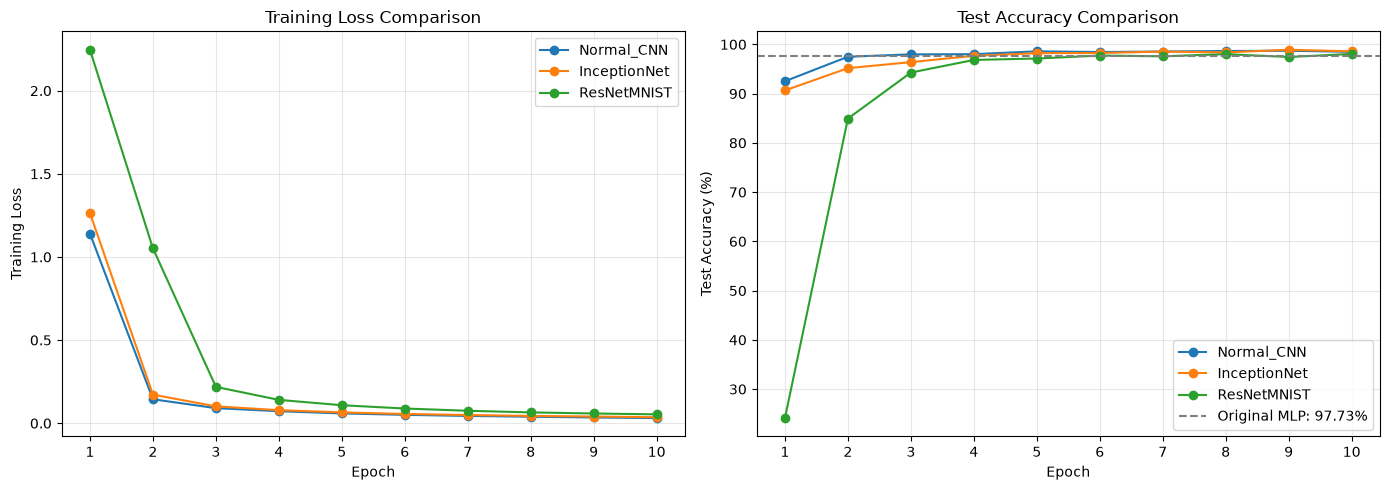

In [16]:
# 识别手写数字

# 1.导入需要的包
import torch
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print('当前训练设备：', device)
# 2.设置批次大小和图片预处理

batch_size =64

transform =transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,),(0.3081,))
])

# 3.加载MNIST训练集和测试集
train_dataset = datasets.MNIST(
    root ='../dataset/mnist/',
    train=True,
    download=True,
    transform = transform
)
test_dataset = datasets.MNIST(
    root ='../dataset/mnist/',
    train=False,
    download=True,
    transform=transform
)

# 4.创建DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# 5.定义CNN：3个卷积块 + 3个全连接层
class CNN(torch.nn.Module):
    def __init__(self,channels=(16,32,64), hidden_dims=(128,64)):
        super().__init__()
        
        # 第一组 28x28 -> 14x14
        self.conv1 = torch.nn.Conv2d(1,channels[0],kernel_size=3,padding=1)
        self.relu1 = torch.nn.ReLU()
        self.pool1 = torch.nn.MaxPool2d(kernel_size=2)

        # 第二组 14x14 -> 7x7
        self.conv2 = torch.nn.Conv2d(channels[0],channels[1],kernel_size=3,padding=1)
        self.relu2 = torch.nn.ReLU()
        self.pool2 = torch.nn.MaxPool2d(kernel_size = 2)

        # 第三组 7x7 -> 3x3
        self.conv3 = torch.nn.Conv2d(channels[1],channels[2],kernel_size=3,padding=1)
        self.relu3 = torch.nn.ReLU()
        self.pool3 = torch.nn.MaxPool2d(kernel_size = 2)

        # Flatten 后尺寸：channels[2] x 3 x 3
        self.fc1 = torch.nn.Linear(channels[2]*3*3,hidden_dims[0])
        self.fc2 = torch.nn.Linear(hidden_dims[0],hidden_dims[1])
        self.fc3 = torch.nn.Linear(hidden_dims[1],10)

    def forward(self,x):
        x=self.pool1(self.relu1(self.conv1(x)))
        x=self.pool2(self.relu2(self.conv2(x)))
        x=self.pool3(self.relu3(self.conv3(x)))

        x = torch.flatten(x,start_dim=1) # 保留 batch维度
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x) 
# 6. 定义损失函数
criterion = torch.nn.CrossEntropyLoss()


# 7. 定义 Inception 模块
class InceptionBlock(torch.nn.Module):
    def __init__(self, in_channels):
        super().__init__()

        # 分支1：1×1卷积
        self.branch1 = torch.nn.Sequential(
            torch.nn.Conv2d(
                in_channels,
                16,
                kernel_size=1
            ),
            torch.nn.ReLU()
        )

        # 分支2：1×1卷积 → 3×3卷积
        self.branch2 = torch.nn.Sequential(
            torch.nn.Conv2d(
                in_channels,
                16,
                kernel_size=1
            ),
            torch.nn.ReLU(),

            torch.nn.Conv2d(
                16,
                24,
                kernel_size=3,
                padding=1
            ),
            torch.nn.ReLU()
        )

        # 分支3：1×1卷积 → 5×5卷积
        self.branch3 = torch.nn.Sequential(
            torch.nn.Conv2d(
                in_channels,
                8,
                kernel_size=1
            ),
            torch.nn.ReLU(),

            torch.nn.Conv2d(
                8,
                8,
                kernel_size=5,
                padding=2
            ),
            torch.nn.ReLU()
        )

        # 分支4：3×3池化 → 1×1卷积
        self.branch4 = torch.nn.Sequential(
            torch.nn.MaxPool2d(
                kernel_size=3,
                stride=1,
                padding=1
            ),

            torch.nn.Conv2d(
                in_channels,
                16,
                kernel_size=1
            ),
            torch.nn.ReLU()
        )

    def forward(self, x):
        output1 = self.branch1(x)
        output2 = self.branch2(x)
        output3 = self.branch3(x)
        output4 = self.branch4(x)

        # 沿通道维度拼接
        output = torch.cat(
            [output1, output2, output3, output4],
            dim=1
        )

        return output

# 定义完整的InceptionNet
class InceptionNet(torch.nn.Module):
    def __init__(self):
        super().__init__()

        # 先把输入通道从1变成16 -> [16,28,28]
        self.cov1 = torch.nn.Sequential(
            torch.nn.Conv2d(
                in_channels = 1,
                out_channels = 16,
                kernel_size =3,
                padding = 1
            ),
        torch.nn.ReLU()            
        )

        # 第一次池化  -> [16,14,14]
        self.pool1  = torch.nn.MaxPool2d(
            kernel_size =2,
            stride = 2
        )

        # 第一个Inception模块
        # [16,14,14] -> [64,14,14]
        self.inception1 = InceptionBlock(
            in_channels = 16
        )

        # 第二次池化 [64,14,14] ->[64,7,7]
        self.pool2 = torch.nn.MaxPool2d(
            kernel_size = 2,
            stride = 2
        )

        # 第二个Inception模块
        self.inception2 = InceptionBlock(
            in_channels = 64
        )

        # 第三次池化 [64,3,3]
        self.pool3 = torch.nn.MaxPool2d(
            kernel_size = 2,
            stride = 2
        )

        # 展平后 ： 64*3*3 =576 
        self.fc1 = torch.nn.Linear(
            64*3*3,
            128
        )
        self.fc2 = torch.nn.Linear(
            128,
            10
        )

    def forward(self,x):
        x = self.cov1(x)
        x = self.pool1(x)

        x = self.inception1(x)
        x = self.pool2(x)

        x = self.inception2(x)
        x = self.pool3(x)

        x = torch.flatten(
            x,
            start_dim = 1
        )

        x =F.relu(self.fc1(x))
        return self.fc2(x)
# 定义通用残差块
class ResidualBlock(torch.nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        # 主路线第一层卷积
        self.conv1 = torch.nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=stride,
            padding=1
        )

        self.relu1 = torch.nn.ReLU()

        # 主路线第二层卷积
        self.conv2 = torch.nn.Conv2d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=1,
            padding=1
        )

        # 默认捷径：直接输出原输入
        self.shortcut = torch.nn.Identity()

        # 通道数或图片尺寸改变时，调整捷径
        if stride != 1 or in_channels != out_channels:
            self.shortcut = torch.nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=1,
                stride=stride
            )

        self.relu2 = torch.nn.ReLU()

    def forward(self, x):
        # 捷径路线
        identity = self.shortcut(x)

        # 主路线 F(x)
        output = self.conv1(x)
        output = self.relu1(output)
        output = self.conv2(output)

        # 残差相加
        output = output + identity

        # 相加后激活
        output = self.relu2(output)

        return output
        
# 定义完整的简化版 ResNet
class ResNetMNIST(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.stem = torch.nn.Sequential(
            torch.nn.Conv2d(
                in_channels = 1,
                out_channels = 16,
                kernel_size = 3,
                padding = 1
            ),
            torch.nn.ReLU()
        )
        self.layer1 = ResidualBlock(
            in_channels = 16,
            out_channels = 16,
            stride = 1
        )

        self.layer2 = ResidualBlock(
            in_channels = 16,
            out_channels =32,
            stride = 2
        )

        self.layer3 = ResidualBlock(
            in_channels = 32,
            out_channels = 64,
            stride = 2
        )

        # 把每个通道的7x7 压缩为 1x1
        #【64,7,7】 -> 【64，1，1】
        self.avg_pool = torch.nn.AdaptiveAvgPool2d(
            output_size=(1,1)
        )

        # 展平之后只有64个特征
        self.fc = torch.nn.Linear(64,10)

    def forward(self,x):
        x = self.stem(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.avg_pool(x)

        x = torch.flatten(x,start_dim = 1)

        return self.fc(x)
        
        
# 8. 训练函数
def train(epoch):
    model.train()

    running_loss = 0.0
    epoch_loss = 0.0

    for batch_idx, data in enumerate(train_loader):
        inputs, target = data

        inputs = inputs.to(device)
        target = target.to(device)

        optimizer.zero_grad()

        output = model(inputs)
        loss = criterion(output, target)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        epoch_loss += loss.item()

        if batch_idx % 300 == 299:
            print(
                '[%d, %5d] loss: %.3f'
                % (
                    epoch + 1,
                    batch_idx + 1,
                    running_loss / 300
                )
            )

            running_loss = 0.0

    return epoch_loss / len(train_loader)


# 9. 测试函数
def test():
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            output = model(images)
            predicted = output.argmax(dim=1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    print(
        'Accuracy on test set: %.2f %%'
        % accuracy
    )

    return accuracy


# 10. 设置模型比较实验
import time

num_epochs = 10

# 这里不再保存模型参数，而是保存“创建模型的方法”
model_builders = {
    "Normal_CNN": lambda: CNN(
        channels=(16, 32, 64),
        hidden_dims=(128, 64)
    ),

    "InceptionNet": lambda: InceptionNet(),
    
    "ResNetMNIST": lambda: ResNetMNIST()
}


results = []
histories = {}


# 11. 依次训练三个模型
for name, build_model in model_builders.items():

    print(f"\n========== 开始训练 {name} ==========")

    # 每个模型开始前重新设置随机种子
    torch.manual_seed(42)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)

    # 根据字典中保存的方法创建模型
    model = build_model().to(device)

    # 每个模型都必须使用一个全新的优化器
    optimizer = optim.SGD(
        model.parameters(),
        lr=0.01,
        momentum=0.5
    )

    train_losses = []
    test_accuracies = []

    start_time = time.perf_counter()

    for epoch in range(num_epochs):

        print(
            f"\n{name}：Epoch {epoch + 1}/{num_epochs}"
        )

        train_loss = train(epoch)
        test_accuracy = test()

        train_losses.append(train_loss)
        test_accuracies.append(test_accuracy)

    elapsed = time.perf_counter() - start_time

    parameters = sum(
        p.numel()
        for p in model.parameters()
    )

    # 保存每个epoch的曲线数据
    histories[name] = {
        "loss": train_losses.copy(),
        "accuracy": test_accuracies.copy()
    }

    # 保存最终比较结果
    results.append({
        "name": name,
        "params": parameters,
        "best_acc": max(test_accuracies),
        "final_acc": test_accuracies[-1],
        "time": elapsed
    })

# 12. 输出模型比较结果
print("\n模型比较结果：")

print(
    f"{'模型':<14}"
    f"{'参数量':>12}"
    f"{'最佳准确率':>14}"
    f"{'最终准确率':>14}"
    f"{'训练时间(s)':>14}"
)

for item in results:
    print(
        f"{item['name']:<14}"
        f"{item['params']:>12,}"
        f"{item['best_acc']:>13.2f}%"
        f"{item['final_acc']:>13.2f}%"
        f"{item['time']:>14.1f}"
    )




# 14. 绘制曲线
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(14, 5))


# 训练损失曲线
plt.subplot(1, 2, 1)

for name, history in histories.items():
    plt.plot(
        epochs,
        history["loss"],
        marker="o",
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")
plt.xticks(epochs)
plt.grid(alpha=0.3)
plt.legend()


# 测试准确率曲线
plt.subplot(1, 2, 2)

for name, history in histories.items():
    plt.plot(
        epochs,
        history["accuracy"],
        marker="o",
        label=name
    )

plt.axhline(
    y=97.73,
    color="gray",
    linestyle="--",
    label="Original MLP: 97.73%"
)

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("Test Accuracy Comparison")
plt.xticks(epochs)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()